<a href="https://colab.research.google.com/github/vickypedia-12/foodle/blob/main/food101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.image as img
import numpy as np
from collections import defaultdict
import collections
from shutil import copy,rmtree, copytree
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import random
import os
import cv2
from tensorflow.keras import regularizers
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, GlobalAveragePooling2D, AveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import backend as K
import zipfile
import os

In [ ]:
print(tf.__version__)
print(tf.test.gpu_device_name())

2.15.0



In [ ]:
def get_data_extract():
    """
    Check if the dataset exists, and if not, download and extract it.
    """
    if "food-101" in os.listdir():
        print("Dataset already exists")
    else:
        print("Downloading the data...")
        !wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
        print("Dataset downloaded!")
        print("Extracting data..")
        !tar xzvf food-101.tar.gz
        print("Extraction done!")

In [ ]:

get_data_extract()


Streaming output truncated to the last 5000 lines.
food-101/images/cannoli/1767088.jpg
food-101/images/cannoli/3201965.jpg
food-101/images/cannoli/3778102.jpg
food-101/images/cannoli/2674065.jpg
food-101/images/cannoli/1169899.jpg
food-101/images/cannoli/1378086.jpg
food-101/images/cannoli/803909.jpg
food-101/images/cannoli/1067240.jpg
food-101/images/cannoli/3002709.jpg
food-101/images/cannoli/2612632.jpg
food-101/images/cannoli/3627612.jpg
food-101/images/cannoli/1798703.jpg
food-101/images/cannoli/560632.jpg
food-101/images/cannoli/512468.jpg
food-101/images/cannoli/2331523.jpg
food-101/images/cannoli/3118302.jpg
food-101/images/cannoli/1499412.jpg
food-101/images/cannoli/1557459.jpg
food-101/images/cannoli/146566.jpg
food-101/images/cannoli/96922.jpg
food-101/images/cannoli/1699562.jpg
food-101/images/cannoli/730051.jpg
food-101/images/cannoli/2177977.jpg
food-101/images/cannoli/2767028.jpg
food-101/images/cannoli/6564.jpg
food-101/images/cannoli/553447.jpg
food-101/images/cannoli/

In [ ]:
!ls food-101/

images	license_agreement.txt  meta  README.txt


In [ ]:
os.listdir('food-101/images')


['ceviche',
 'foie_gras',
 'prime_rib',
 'bread_pudding',
 'cup_cakes',
 'tacos',
 'beet_salad',
 'pulled_pork_sandwich',
 'mussels',
 'peking_duck',
 'oysters',
 'apple_pie',
 'french_toast',
 'carrot_cake',
 'edamame',
 'macaroni_and_cheese',
 'baklava',
 'baby_back_ribs',
 'chicken_curry',
 'shrimp_and_grits',
 'chocolate_cake',
 'frozen_yogurt',
 'bibimbap',
 'chicken_wings',
 'ramen',
 'grilled_salmon',
 'fish_and_chips',
 'caesar_salad',
 'pho',
 'garlic_bread',
 'takoyaki',
 'lobster_bisque',
 'pad_thai',
 'ravioli',
 'cheesecake',
 'lobster_roll_sandwich',
 'gyoza',
 'spaghetti_bolognese',
 'hot_and_sour_soup',
 'ice_cream',
 'tuna_tartare',
 'macarons',
 'risotto',
 'hamburger',
 'eggs_benedict',
 'filet_mignon',
 'escargots',
 'french_fries',
 'churros',
 'spaghetti_carbonara',
 'guacamole',
 'deviled_eggs',
 'creme_brulee',
 'crab_cakes',
 'cheese_plate',
 'omelette',
 'seaweed_salad',
 'strawberry_shortcake',
 'gnocchi',
 'clam_chowder',
 'waffles',
 'miso_soup',
 'panna_co

In [ ]:
os.listdir('food-101/meta')


['train.json',
 'classes.txt',
 'labels.txt',
 'test.json',
 'train.txt',
 'test.txt']

In [ ]:
!head food-101/meta/train.txt

apple_pie/1005649
apple_pie/1014775
apple_pie/1026328
apple_pie/1028787
apple_pie/1043283
apple_pie/1050519
apple_pie/1057749
apple_pie/1057810
apple_pie/1072416
apple_pie/1074856


In [ ]:
!head food-101/meta/classes.txt

apple_pie
baby_back_ribs
baklava
beef_carpaccio
beef_tartare
beet_salad
beignets
bibimbap
bread_pudding
breakfast_burrito


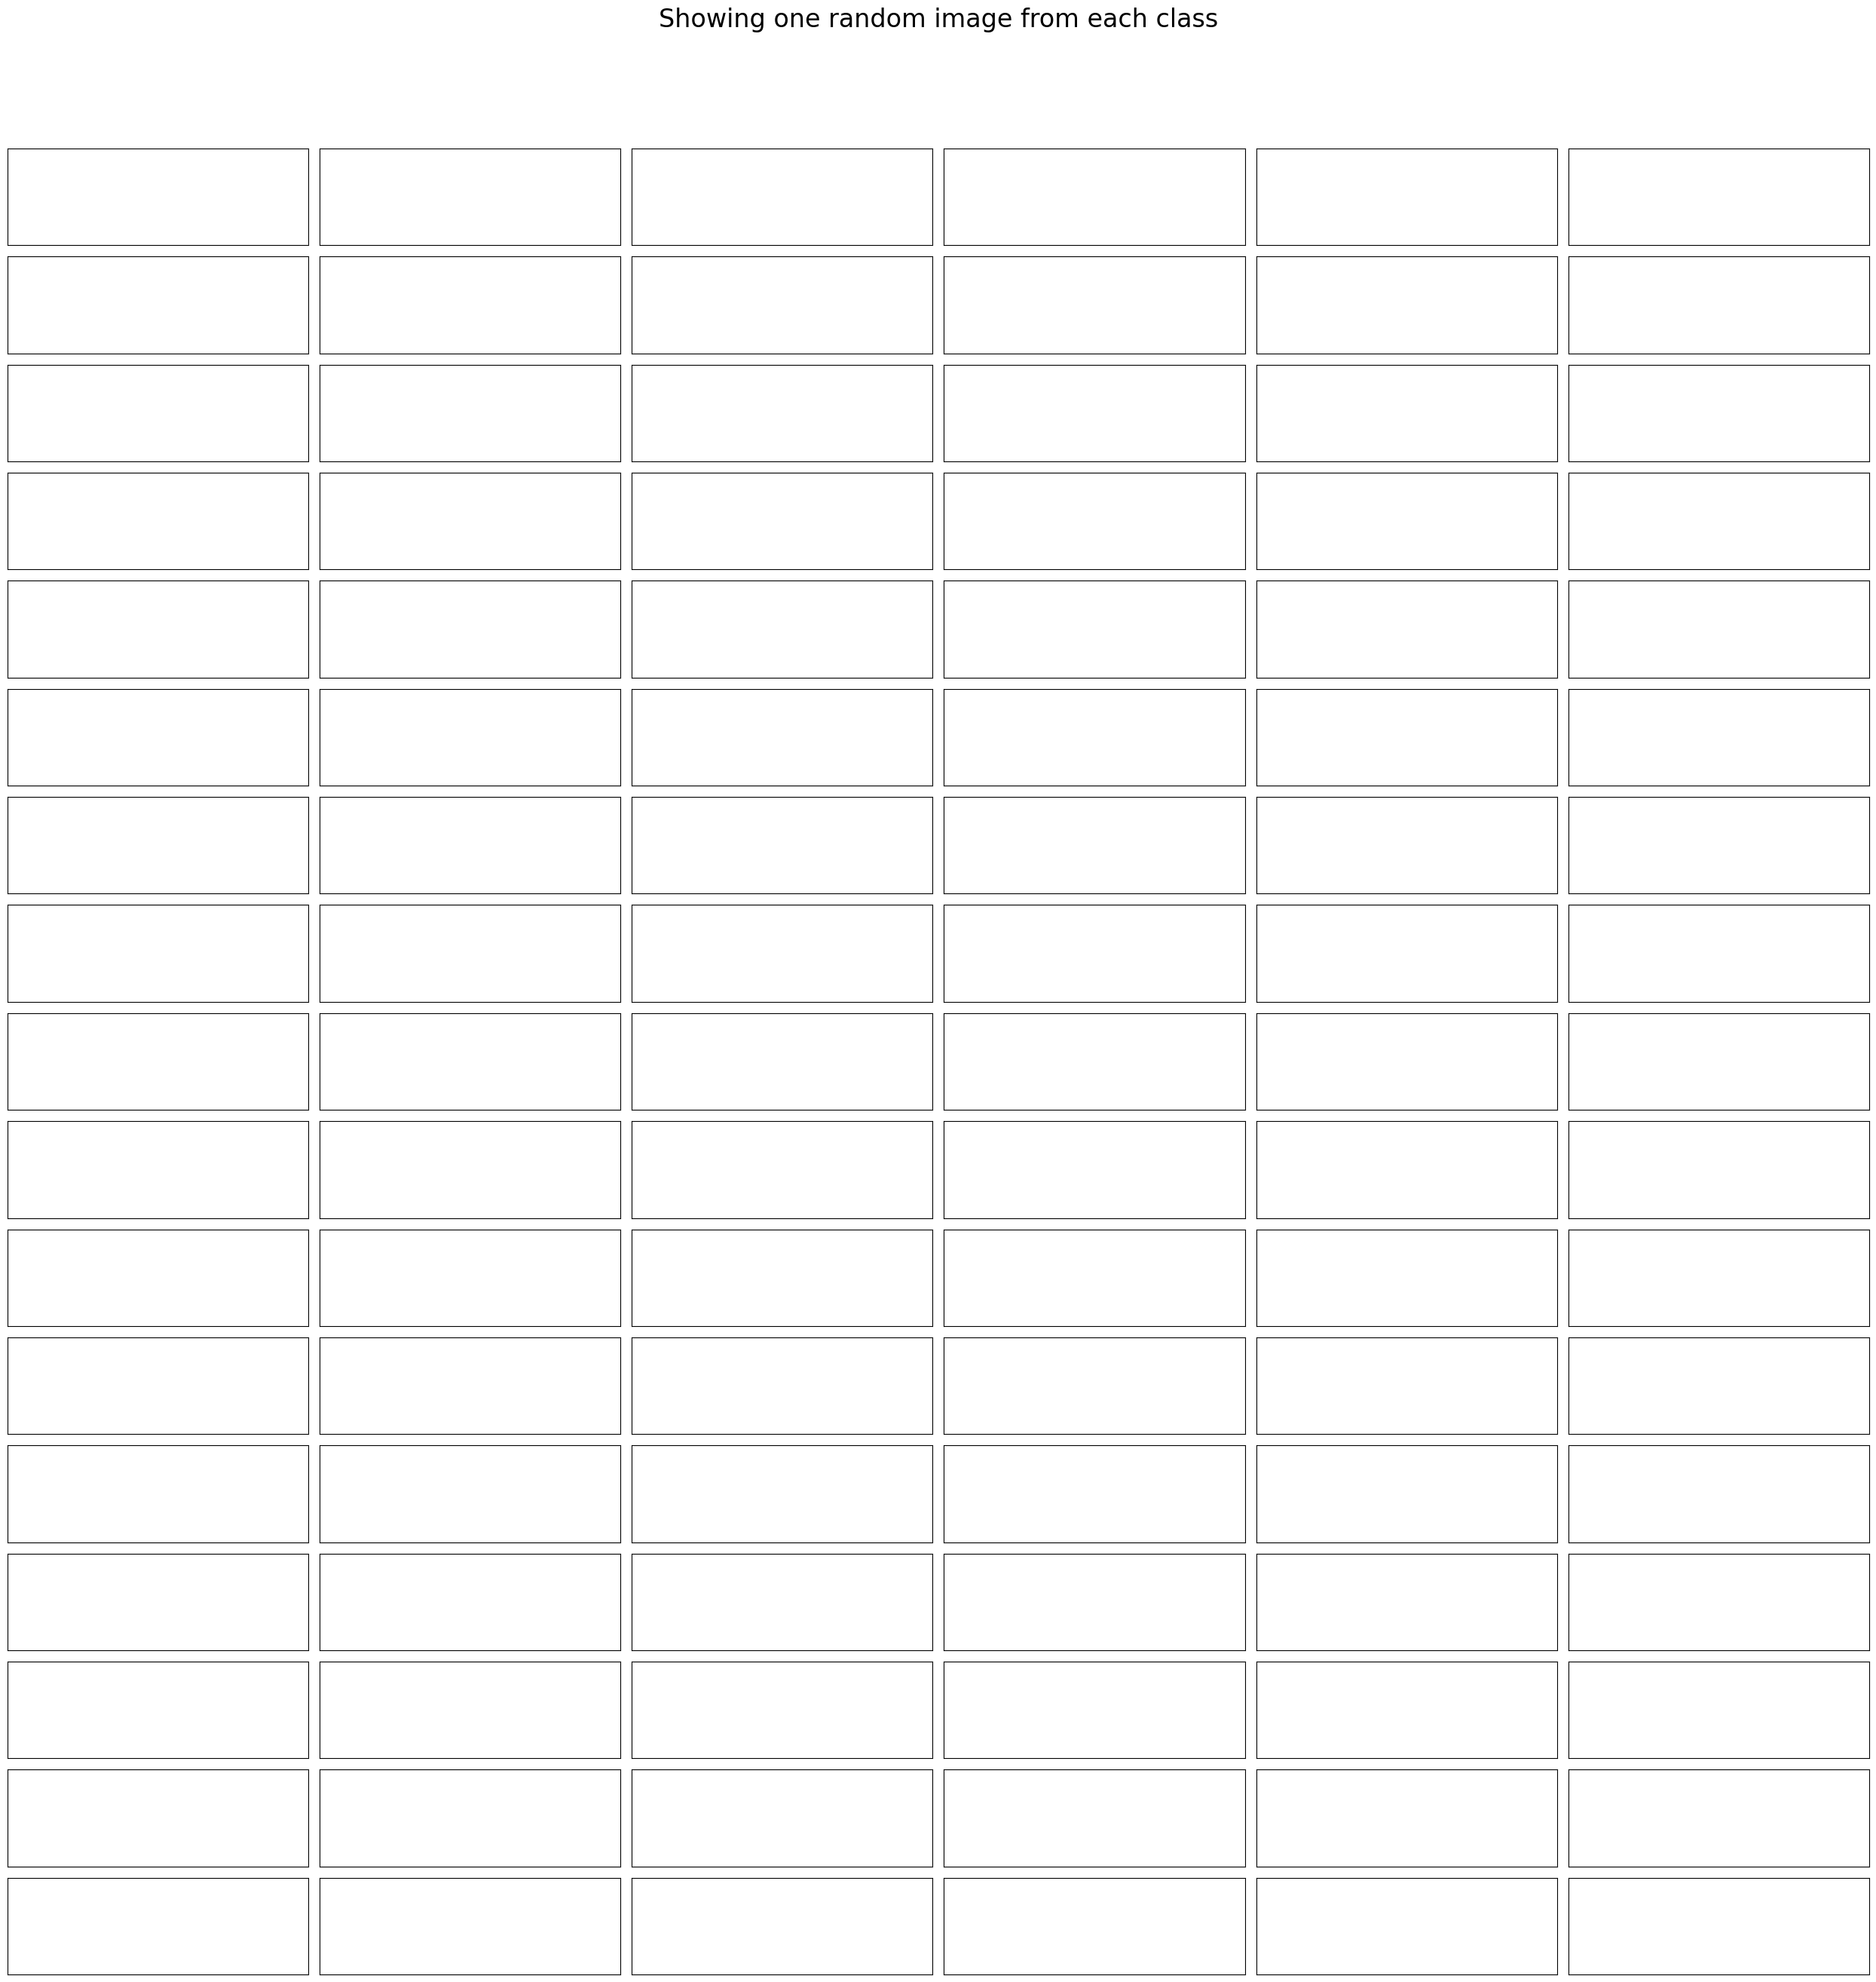

In [ ]:
rows = 17
cols = 6
fig, ax = plt.subplots(rows, cols, figsize=(25,25))
fig.suptitle("Showing one random image from each class", y=1.05, fontsize=24)
data_dir = "food-101/images/"
food_id = 0
for i in range(rows):
    for j in range(cols):
        try:
            food_selected = foods_sorted[food_id]
            food_id += 1
        except:
            break
        if food_selected == '.DS_Store':
            continue
        food_selected_images = os.listdir(os.path.join(data_dir, food_selected))

        food_selected_random = np.random.choice(food_selected_images)

        img = plt.imread(os.path.join(data_dir, food_selected, food_selected_random))
        ax[i][j].imshow(img)
        ax[i][j].set_title(food_selected, pad=10)

plt.setp(ax, xticks=[], yticks=[])
plt.tight_layout()


In [ ]:
def prepare_data(filepath, src, dest):
  classes_images = defaultdict(list)
  with open(filepath, 'r') as txt:
        paths = [read.strip() for read in txt.readlines()]
        for p in paths:
            food = p.split('/')
            classes_images[food[0]].append(food[1] + '.jpg')
  for food in classes_images.keys():
        print("\nCopying images into ", food)
        if not os.path.exists(os.path.join(dest, food)):
            os.makedirs(os.path.join(dest, food))
        for i in classes_images[food]:
            copy(os.path.join(src, food, i), os.path.join(dest, food, i))
  print("Copying Done!")


In [ ]:
prepare_data('/content/food-101/meta/train.txt', '/content/food-101/images', 'train')


Copying images into  apple_pie

Copying images into  baby_back_ribs

Copying images into  baklava

Copying images into  beef_carpaccio

Copying images into  beef_tartare

Copying images into  beet_salad

Copying images into  beignets

Copying images into  bibimbap

Copying images into  bread_pudding

Copying images into  breakfast_burrito

Copying images into  bruschetta

Copying images into  caesar_salad

Copying images into  cannoli

Copying images into  caprese_salad

Copying images into  carrot_cake

Copying images into  ceviche

Copying images into  cheesecake

Copying images into  cheese_plate

Copying images into  chicken_curry

Copying images into  chicken_quesadilla

Copying images into  chicken_wings

Copying images into  chocolate_cake

Copying images into  chocolate_mousse

Copying images into  churros

Copying images into  clam_chowder

Copying images into  club_sandwich

Copying images into  crab_cakes

Copying images into  creme_brulee

Copying images into  croque_madam

In [ ]:
prepare_data('/content/food-101/meta/test.txt', '/content/food-101/images', 'test')


Copying images into  apple_pie

Copying images into  baby_back_ribs

Copying images into  baklava

Copying images into  beef_carpaccio

Copying images into  beef_tartare

Copying images into  beet_salad

Copying images into  beignets

Copying images into  bibimbap

Copying images into  bread_pudding

Copying images into  breakfast_burrito

Copying images into  bruschetta

Copying images into  caesar_salad

Copying images into  cannoli

Copying images into  caprese_salad

Copying images into  carrot_cake

Copying images into  ceviche

Copying images into  cheesecake

Copying images into  cheese_plate

Copying images into  chicken_curry

Copying images into  chicken_quesadilla

Copying images into  chicken_wings

Copying images into  chocolate_cake

Copying images into  chocolate_mousse

Copying images into  churros

Copying images into  clam_chowder

Copying images into  club_sandwich

Copying images into  crab_cakes

Copying images into  creme_brulee

Copying images into  croque_madam

In [ ]:
!find train -type d -or -type f -printf '.' | wc -c


75750


In [ ]:
!find test -type d -or -type f -printf '.' | wc -c

25250


In [ ]:
def dataset_mini(food_list, src, dest):
    # Check if the destination directory exists
    if os.path.exists(dest):
        # If it exists, remove it to ensure a clean slate
        rmtree(dest)  # Removing dataset_mini (if it already exists) folders
    # Create the destination directory
    os.makedirs(dest)

    # Iterate over each food item in the provided list
    for food_item in food_list:
        print("Copying images into", food_item)
        # Recursively copy the images from the source directory to the destination directory for each food item
        copytree(os.path.join(src, food_item), os.path.join(dest, food_item))


In [ ]:
food_list = ['apple_pie', 'pizza', 'omelette']

# Source and destination directories for train and test datasets
src_train = 'train'
dest_train = 'train_mini'
src_test = 'test'
dest_test = 'test_mini'

# Create train_mini dataset
dataset_mini(food_list, src_train, dest_train)

# Create test_mini dataset
dataset_mini(food_list, src_test, dest_test)

Copying images into apple_pie
Copying images into pizza
Copying images into omelette
Copying images into apple_pie
Copying images into pizza
Copying images into omelette


In [ ]:
print("Creating train data folder with new classes")

# Create train_mini dataset with specified food classes
dataset_mini(food_list, src_train, dest_train)

Creating train data folder with new classes
Copying images into apple_pie
Copying images into pizza
Copying images into omelette


In [ ]:
!find train_mini -type d -or -type f -printf '.' | wc -c

2250


In [ ]:
dataset_mini(food_list, src_test, dest_test)

Copying images into apple_pie
Copying images into pizza
Copying images into omelette


In [ ]:
!find test_mini -type d -or -type f -printf '.' | wc -c


750


In [ ]:

K.clear_session()

# Number of classes in the dataset
n_classes = 3

# Image dimensions
img_width, img_height = 299, 299

# Directories for training and validation data
train_data_dir = 'train_mini'
validation_data_dir = 'test_mini'

# Number of samples in the training and validation sets
nb_train_samples = 2250  # Number of training samples
nb_validation_samples = 750  # Number of validation samples

# Batch size for training
batch_size = 16

train_datagen = ImageDataGenerator(
    rescale=1. / 255,  # Normalize pixel values to the range [0,1]
    shear_range=0.2,   # Shear transformation
    zoom_range=0.2,    # Random zoom
    horizontal_flip=True)  # Horizontal flip

# Normalization for validation images
test_datagen = ImageDataGenerator(rescale=1. / 255)  # Normalize pixel values to the range [0,1]

# Generate batches of training data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,  # Path to the training data directory
    target_size=(img_height, img_width),  # Resize images to match the input size of the model
    batch_size=batch_size,  # Number of samples per batch
    class_mode='categorical')  # Use categorical labels for multi-class classification

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,  # Path to the validation data directory
    target_size=(img_height, img_width),  # Resize images to match the input size of the model
    batch_size=batch_size,  # Number of samples per batch
    class_mode='categorical')  # Use categorical labels for multi-class classification

# Load the pre-trained InceptionV3 model without the top layers
inception = InceptionV3(weights='imagenet', include_top=False)

# Add custom top layers for fine-tuning
x = inception.output  # Output tensor of the InceptionV3 model
x = GlobalAveragePooling2D()(x)  # Global average pooling layer
x = Dense(128, activation='relu')(x)  # Fully connected layer with ReLU activation
x = Dropout(0.2)(x)  # Dropout layer for regularization

# Predictions layer with softmax activation for class probabilities
predictions = Dense(3, kernel_regularizer=regularizers.l2(0.005), activation='softmax')(x)

# Create the final model with InceptionV3 as the base and custom top layers
model = Model(inputs=inception.input, outputs=predictions)

model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks for saving the best model and logging training history
checkpointer = ModelCheckpoint(filepath='best_model_3class.hdf5', verbose=1, save_best_only=True)
csv_logger = CSVLogger('history_3class.log')

# Train the model using the training and validation generators
history = model.fit(
    train_generator,
    steps_per_epoch=nb_train_samples // batch_size,  # Number of batches per epoch
    validation_data=validation_generator,
    validation_steps=nb_validation_samples // batch_size,  # Number of validation batches per epoch
    epochs=30,  # Number of training epochs
    verbose=1,  # Verbosity mode (0=silent, 1=progress bar, 2=one line per epoch)
    callbacks=[csv_logger, checkpointer])  # List of callbacks for training
model.save('model_trained_3class.hdf5')

Found 2250 images belonging to 3 classes.
Found 750 images belonging to 3 classes.
87910968/87910968 [==============================] - 0s 0us/step
Epoch 1/30
140/140 [==============================] - ETA: 0s - loss: 1.0345 - accuracy: 0.5094
Epoch 1: val_loss improved from inf to 0.81801, saving model to best_model_3class.hdf5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


140/140 [==============================] - 102s 507ms/step - loss: 1.0345 - accuracy: 0.5094 - val_loss: 0.8180 - val_accuracy: 0.7432
Epoch 2/30
140/140 [==============================] - ETA: 0s - loss: 0.8092 - accuracy: 0.6970
Epoch 2: val_loss improved from 0.81801 to 0.63505, saving model to best_model_3class.hdf5
140/140 [==============================] - 64s 455ms/step - loss: 0.8092 - accuracy: 0.6970 - val_loss: 0.6351 - val_accuracy: 0.8261
Epoch 3/30
140/140 [==============================] - ETA: 0s - loss: 0.6594 - accuracy: 0.7789
Epoch 3: val_loss improved from 0.63505 to 0.50219, saving model to best_model_3class.hdf5
140/140 [==============================] - 63s 453ms/step - loss: 0.6594 - accuracy: 0.7789 - val_loss: 0.5022 - val_accuracy: 0.8736
Epoch 4/30
140/140 [==============================] - ETA: 0s - loss: 0.5671 - accuracy: 0.8071
Epoch 4: val_loss improved from 0.50219 to 0.42138, saving model to best_model_3class.hdf5
140/140 [===========================

In [ ]:
class_map_3 = train_generator.class_indices

# Display the class indices mapping
class_map_3

{'apple_pie': 0, 'omelette': 1, 'pizza': 2}

In [ ]:
def plot_accuracy(history, title):
    """
    Plot training and validation accuracy over epochs.

    Args:
    - history: Training history obtained from model training
    - title: Title of the plot

    Returns:
    - None
    """
    plt.title(title)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train_accuracy', 'validation_accuracy'], loc='best')
    plt.show()

def plot_loss(history, title):
    """
    Plot training and validation loss over epochs.

    Args:
    - history: Training history obtained from model training
    - title: Title of the plot

    Returns:
    - None
    """
    plt.title(title)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train_loss', 'validation_loss'], loc='best')
    plt.show()

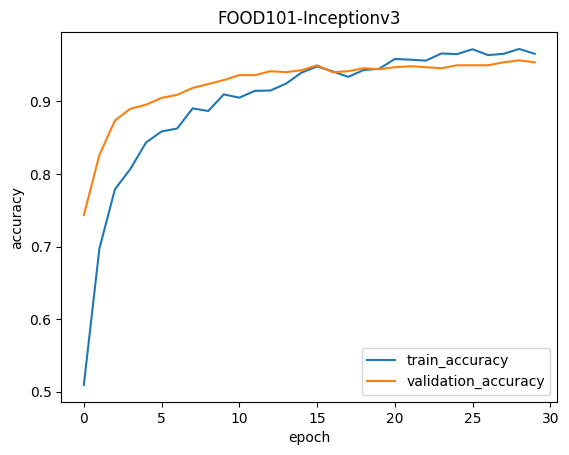

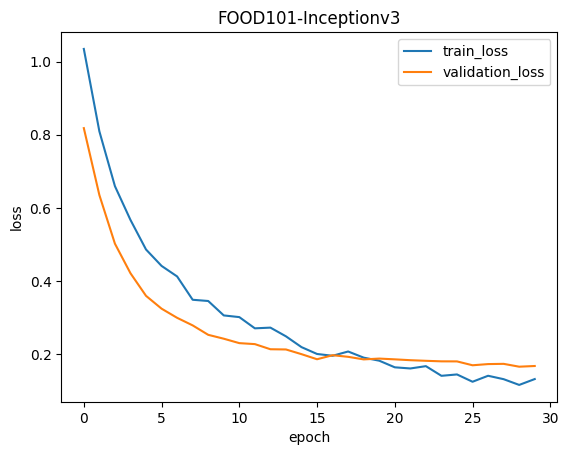

In [ ]:
plot_accuracy(history, 'FOOD101-Inceptionv3')  # Plot training and validation accuracy
plot_loss(history, 'FOOD101-Inceptionv3')

In [ ]:
%%time
# Loading the best saved model to make predictions
K.clear_session()  # Clear Keras session
model_best = load_model('best_model_3class.hdf5', compile=False)

CPU times: user 3.04 s, sys: 85.6 ms, total: 3.13 s
Wall time: 3.2 s


In [ ]:
def predict_class(model, images, show=True):
      for img in images:
        img = image.load_img(img, target_size=(299, 299))  # Load image and resize to model's input size
        img = image.img_to_array(img)                     # Convert image to numpy array
        img = np.expand_dims(img, axis=0)                 # Add batch dimension
        img /= 255.                                       # Normalize pixel values

        pred = model.predict(img)                         # Make prediction
        index = np.argmax(pred)                           # Get the index of the class with the highest probability
        food_list.sort()                                  # Sort the list of food items
        pred_value = food_list[index]                     # Get the predicted class label

        if show:
            plt.imshow(img[0])                           # Display the image
            plt.axis('off')
            plt.title(pred_value)                        # Set title as the predicted class label
            plt.show()

In [ ]:
!wget -O samosa.jpg http://veggiefoodrecipes.com/wp-content/uploads/2016/05/lentil-samosa-recipe-01.jpg
!wget -O applepie.jpg https://acleanbake.com/wp-content/uploads/2017/10/Paleo-Apple-Pie-with-Crumb-Topping-gluten-free-grain-free-dairy-free-15.jpg
!wget -O pizza.jpg http://104.130.3.186/assets/itemimages/400/400/3/default_9b4106b8f65359684b3836096b4524c8_pizza%20dreamstimesmall_94940296.jpg
!wget -O omelette.jpg https://www.incredibleegg.org/wp-content/uploads/basic-french-omelet-930x550.jpg

--2024-03-29 17:22:36--  http://veggiefoodrecipes.com/wp-content/uploads/2016/05/lentil-samosa-recipe-01.jpg
Resolving veggiefoodrecipes.com (veggiefoodrecipes.com)... 104.21.79.5, 172.67.139.59, 2606:4700:3037::ac43:8b3b, ...
Connecting to veggiefoodrecipes.com (veggiefoodrecipes.com)|104.21.79.5|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://veggiefoodrecipes.com/wp-content/uploads/2016/05/lentil-samosa-recipe-01.jpg [following]
--2024-03-29 17:22:36--  https://veggiefoodrecipes.com/wp-content/uploads/2016/05/lentil-samosa-recipe-01.jpg
Connecting to veggiefoodrecipes.com (veggiefoodrecipes.com)|104.21.79.5|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2024-03-29 17:22:37 ERROR 404: Not Found.

--2024-03-29 17:22:37--  https://acleanbake.com/wp-content/uploads/2017/10/Paleo-Apple-Pie-with-Crumb-Topping-gluten-free-grain-free-dairy-free-15.jpg
Resolving acleanbake.com (acleanbake.com)... 138.197.203.41
Conne

1/1 [==============================] - 0s 30ms/step


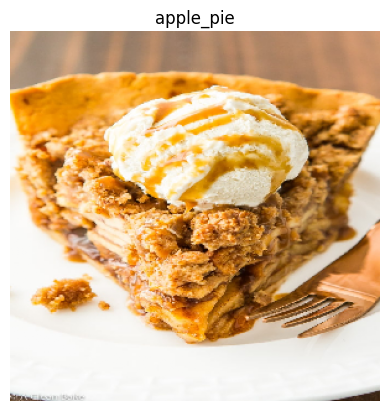

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7be5997398a0>

In [ ]:
images = ['applepie.jpg', 'pizza.jpg', 'omelette.jpg']

# Test the trained model
predict_class(model_best, images, True)

In [ ]:
def pick_n_random_classes(n):
    """
    Select n random food classes from the sorted list of food items.

    Args:
    - n: Number of random food classes to select

    Returns:
    - List of n randomly selected food classes
    """
    foods_sorted = ['escargots',
 'prime_rib',
 'chicken_wings',
 'grilled_salmon',
 'pulled_pork_sandwich',
 'clam_chowder',
 'chocolate_mousse',
 'beet_salad',
 'cheese_plate',
 'scallops',
 'cheesecake',
 'garlic_bread',
 'ice_cream',
 'nachos',
 'steak',
 'frozen_yogurt',
 'lasagna',
 'pancakes',
 'macarons',
 'shrimp_and_grits',
 'strawberry_shortcake',
 'huevos_rancheros',
 'spaghetti_bolognese',
 'pho',
 'sashimi',
 'breakfast_burrito',
 'caesar_salad',
 'hot_dog',
 'miso_soup',
 'panna_cotta',
 'greek_salad',
 'eggs_benedict',
 'lobster_bisque',
 'bread_pudding',
 'fish_and_chips',
 'omelette',
 'tuna_tartare',
 'chocolate_cake',
 'french_toast',
 'ramen',
 'mussels',
 'bibimbap',
 'french_fries',
 'chicken_quesadilla',
 'macaroni_and_cheese',
 'gnocchi',
 'fried_calamari',
 'donuts',
 'sushi',
 'filet_mignon',
 'beef_carpaccio',
 'churros',
 'beignets',
 'spring_rolls',
 'ceviche',
 'onion_rings',
 'crab_cakes',
 'guacamole',
 'baby_back_ribs',
 'dumplings',
 'peking_duck',
 'apple_pie',
 'pizza',
 'chicken_curry',
 'french_onion_soup',
 'deviled_eggs',
 'red_velvet_cake',
 'risotto',
 'samosa',
 'seaweed_salad',
 'hummus',
 'hamburger',
 'tacos',
 'oysters',
 'fried_rice',
 'gyoza',
 'cannoli',
 'caprese_salad',
 'falafel',
 'edamame',
 'takoyaki',
 'waffles',
 'club_sandwich',
 'tiramisu',
 'carrot_cake',
 'baklava',
 'spaghetti_carbonara',
 'croque_madame',
 'beef_tartare',
 'pad_thai',
 'poutine',
 'cup_cakes',
 'foie_gras',
 'pork_chop',]
    food_list = []
    random_food_indices = random.sample(range(len(foods_sorted)), n)  # Sample n random indices
    for i in random_food_indices:
        food_list.append(foods_sorted[i])  # Retrieve corresponding food items
    food_list.sort()  # Sort the list of randomly selected food classes
    return food_list

In [ ]:
n = 11  # Number of random food classes to select
food_list = pick_n_random_classes(n)  # Select n random food classes
food_list = ['apple_pie', 'beef_carpaccio', 'bibimbap', 'cup_cakes', 'foie_gras', 'french_fries', 'garlic_bread', 'pizza', 'spring_rolls', 'spaghetti_carbonara', 'strawberry_shortcake']
print("These are the randomly picked food classes we will be training the model on...\n", food_list)

These are the randomly picked food classes we will be training the model on...
 ['apple_pie', 'beef_carpaccio', 'bibimbap', 'cup_cakes', 'foie_gras', 'french_fries', 'garlic_bread', 'pizza', 'spring_rolls', 'spaghetti_carbonara', 'strawberry_shortcake']


In [ ]:
print("Creating training data folder with new classes...")

# Call the dataset_mini function to create a new data subset with the selected food classes for training
dataset_mini(food_list, src_train, dest_train)

Creating training data folder with new classes...
Copying images into apple_pie
Copying images into beef_carpaccio
Copying images into bibimbap
Copying images into cup_cakes
Copying images into foie_gras
Copying images into french_fries
Copying images into garlic_bread
Copying images into pizza
Copying images into spring_rolls
Copying images into spaghetti_carbonara
Copying images into strawberry_shortcake


In [ ]:
# Print the total number of samples in the train folder
print("Total number of samples in train folder")

# Count the number of files and directories in the train_mini folder and print the count
!find train_mini -type d -or -type f -printf '.' | wc -c

Total number of samples in train folder
8250


In [ ]:
print("Creating test data folder with new classes")

# Call the dataset_mini function to create a new data subset with the selected food classes for testing
dataset_mini(food_list, src_test, dest_test)

Creating test data folder with new classes
Copying images into apple_pie
Copying images into beef_carpaccio
Copying images into bibimbap
Copying images into cup_cakes
Copying images into foie_gras
Copying images into french_fries
Copying images into garlic_bread
Copying images into pizza
Copying images into spring_rolls
Copying images into spaghetti_carbonara
Copying images into strawberry_shortcake


In [ ]:
print("Total number of samples in test folder")

# Count the number of files and directories in the test_mini folder and print the count
!find test_mini -type d -or -type f -printf '.' | wc -c

Total number of samples in test folder
2750


In [ ]:
K.clear_session()

# Set the number of classes
n_classes = n

# Set the dimensions of input images
img_width, img_height = 299, 299

# Set the paths for the training and validation data directories
train_data_dir = 'train_mini'
validation_data_dir = 'test_mini'

# Set the number of training and validation samples
nb_train_samples = 8250
nb_validation_samples = 2750

# Set the batch size for training
batch_size = 40

train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

# Define data augmentation for validation images
test_datagen = ImageDataGenerator(rescale=1. / 255)

# Generate batches of augmented training and validation data
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical')

# Load the InceptionV3 model pretrained on ImageNet without the top layer
inception = InceptionV3(weights='imagenet', include_top=False)

# Add custom top layers for classification
x = inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
predictions = Dense(n, kernel_regularizer=regularizers.l2(0.005), activation='softmax')(x)

model = Model(inputs=inception.input, outputs=predictions)

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks for model checkpointing and logging
checkpointer = ModelCheckpoint(filepath='best_model_class.hdf5', verbose=1, save_best_only=True)
csv_logger = CSVLogger('history_class.log')

# Train the model
history_11class = model.fit(train_generator,
                    steps_per_epoch=nb_train_samples // batch_size,
                    validation_data=validation_generator,
                    validation_steps=nb_validation_samples // batch_size,
                    epochs=30,
                    verbose=1,
                    callbacks=[csv_logger, checkpointer])

# Save the trained model
model.save('model_trained_class.hdf5')

NameError: name 'K' is not defined

In [ ]:
class_map = train_generator.class_indices
class_map

In [ ]:
plot_accuracy(history_class, 'FOOD101-Inceptionv3')

# Plot the loss over epochs for the training and validation sets
plot_loss(history_class, 'FOOD101-Inceptionv3')

In [ ]:
%%time
# Clear any previous session and load the best saved model for predictions
K.clear_session()
model_best = load_model('best_model_class.hdf5', compile=False)

In [ ]:
!wget -O cupcakes.jpg https://www.publicdomainpictures.net/pictures/110000/nahled/halloween-witch-cupcakes.jpg
!wget -O springrolls.jpg https://upload.wikimedia.org/wikipedia/commons/6/6f/Vietnamese_spring_rolls.jpg
# !wget -O pizza.jpg http://104.130.3.186/assets/itemi  mages/400/400/3/default_9b4106b8f65359684b3836096b4524c8_pizza%20dreamstimesmall_94940296.jpg
!wget -O garlicbread.jpg https://c1.staticflickr.com/1/84/262952165_7ba3466108_z.jpg?zz=1

In [ ]:
images = []
images.append('cupcakes.jpg')
images.append('pizza.jpg')
images.append('springrolls.jpg')
images.append('garlicbread.jpg')
predict_class(model_best, images, True)